# 🔎 Bias Lab

### ¿Puede un modelo aprender que ciertas profesiones "tienen género"?

Vamos a recorrer el mismo experimento cinco veces, cada vez con más profundidad:

| Acto | Pregunta |
|---|---|
| 1. Datos | ¿Qué realidad le estamos mostrando al modelo? |
| 2. Modelo | ¿Qué aprende de esa realidad? (3 formas de representar texto) |
| 3. Benchmark | ¿Cómo sabemos si funciona? |
| 4. Sesgo deliberado | ¿Funciona igual para todos? |
| 5. WinoMT | ¿Qué pasa cuando lo probamos afuera del dataset de entrenamiento? |

**La tarea:** dado el contexto de una oración (con la profesión y el/los
pronombres tapados), predecir si la persona es *male* o *female*. Tapamos
esas dos cosas para que el modelo no "lea la respuesta" en el propio
enunciado — lo único que le queda es el contexto, el mismo tipo de pistas
(estereotipadas o no) que usaría una persona.

**¿Cuántas clases de salida tiene este modelo?** Una vez limpios los datos
(Acto 1), el problema queda como **clasificación binaria: 2 clases posibles**
&mdash; `male` (0) o `female` (1). Un solo label por oración, nunca las dos
a la vez (no es multi-label) y nunca más de dos opciones (no es multi-clase).

In [228]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "biaslab").is_dir():
            return p
    raise RuntimeError("No encuentro la carpeta 'biaslab'. ¿Corriste ./setup.sh?")


ROOT = find_root(Path.cwd())
sys.path.insert(0, str(ROOT))
DATA_DIR = ROOT / "data"
CACHE_DIR = ROOT / "cache"

from biaslab.data import load_bug, load_winomt
from biaslab.evaluation import slice_report, profession_breakdown, summarize

pd.set_option("display.precision", 3)

---
## 1. Los datos

`gold_BUG` son oraciones reales (Wikipedia + noticias de COVID) donde
aparece una profesión y un pronombre que se refiere a esa persona,
**validadas a mano**. Es el dataset tal cual salió del mundo, sin tocar nada.

Antes de tocar nada, veamos qué trae el archivo **crudo** (`gold_BUG.csv`)
tal cual lo bajamos, sin pasar por nuestro código. Estas son sus columnas:

| Columna | Qué es |
|---|---|
| `uid` | Identificador único de la fila |
| `sentence_text` | La oración completa, tal cual aparece en el texto original |
| `tokens` | La misma oración partida en palabras (lista de tokens) |
| `profession` | La palabra de profesión/ocupación que aparece en la oración |
| `g` | El pronombre que se refiere a esa persona (`he`, `she`, `his`, `her`...) |
| `profession_first_index` | En qué posición de `tokens` aparece la profesión |
| `g_first_index` | En qué posición de `tokens` aparece el pronombre |
| `predicted gender` | El género que el pipeline de BUG **infirió automáticamente del pronombre** (`he/him/his`→male, `she/her/hers`→female) — no es una verificación real de identidad de género. **Esto es lo que vamos a predecir** (el *label*) |
| `stereotype` | `1` = el género coincide con el estereotipo ocupacional típico, `-1` = lo contradice, `0` = sin estereotipo fuerte |
| `distance` | Qué tan lejos está el pronombre de la profesión, en cantidad de palabras |
| `num_of_pronouns` | Cuántos pronombres hay en toda la oración |
| `corpus` | De qué fuente viene la oración (Wikipedia, noticias de COVID, etc.) |
| `data_index` | Índice interno del dataset original |

**Importante:** `predicted gender` no lo anotó una persona mirando a cada individuo — es una heurística: el pronombre que el parser detectó como correferente de la profesión, mapeado directo a género gramatical. En `gold_BUG` esa predicción automática fue **revisada a mano** (de ahí el nombre "gold"); en `balanced_BUG`/`full_BUG` es la salida cruda del pipeline, sin validar fila por fila. El propio dataset ya asume "pronombre usado = género de la persona" — una simplificación binaria que forma parte de la conversación sobre sesgo que estamos teniendo hoy.

In [229]:
raw_gold = pd.read_csv(DATA_DIR / "bug" / "gold_BUG.csv")
raw_gold.head(10)

,Unnamed: 0,uid,sentence_text,tokens,profession,g,profession_first_index,g_first_index,predicted gender,stereotype,distance,num_of_pronouns,corpus,data_index
0,0,0,"My friend , who grew up in Africa , explained ...","['My', 'friend', ',', 'who', 'grew', 'up', 'in...",friend,he,1,16,Male,0,15,2,covid19,4
1,1,1,"â€¢ Lastly , for the patient that did not need...","['â€¢', 'Lastly', ',', 'for', 'the', 'patient'...",patient,his,5,17,Male,0,12,1,covid19,6
2,2,2,Her early years as a resident doctor in the No...,"['Her', 'early', 'years', 'as', 'a', 'resident...",doctor,her,6,12,Female,-1,6,2,covid19,17
3,3,3,"Another participant stated , "" Without network...","['Another', 'participant', 'stated', ',', '""',...",teacher,she,61,69,Female,1,8,3,covid19,4
4,4,4,The patient followed up in the nephrology clin...,"['The', 'patient', 'followed', 'up', 'in', 'th...",patient,his,1,17,Male,0,16,1,covid19,17
5,5,5,A person falsely tested negative incorrectly r...,"['A', 'person', 'falsely', 'tested', 'negative...",person,she,1,9,Female,1,8,2,covid19,4
6,6,6,The author declares that he is the sole author...,"['The', 'author', 'declares', 'that', 'he', 'i...",author,he,1,13,Male,-1,12,2,covid19,4
7,7,7,Now Lesly 's body aches with symptoms of COVID...,"['Now', 'Lesly', ""'s"", 'body', 'aches', 'with'...",doctor,she,23,26,Female,-1,3,5,covid19,4
8,8,8,This patient achieved recovery of her immunolo...,"['This', 'patient', 'achieved', 'recovery', 'o...",patient,her,1,5,Female,0,4,1,covid19,17
9,9,9,"In these cases , the index patient was intubat...","['In', 'these', 'cases', ',', 'the', 'index', ...",patient,his,6,15,Male,0,9,1,covid19,1


¿Cuánta información tiene en total? Uno de los primeros chequeos en cualquier EDA:

In [230]:
print(f"{raw_gold.shape[0]} filas x {raw_gold.shape[1]} columnas")
raw_gold.info()

1717 filas x 14 columnas
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1717 entries, 0 to 1716
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Unnamed: 0              1717 non-null   int64 
 1   uid                     1717 non-null   int64 
 2   sentence_text           1717 non-null   object
 3   tokens                  1717 non-null   object
 4   profession              1717 non-null   object
 5   g                       1717 non-null   object
 6   profession_first_index  1717 non-null   int64 
 7   g_first_index           1717 non-null   int64 
 8   predicted gender        1717 non-null   object
 9   stereotype              1717 non-null   int64 
 10  distance                1717 non-null   int64 
 11  num_of_pronouns         1717 non-null   int64 
 12  corpus                  1717 non-null   object
 13  data_index              1717 non-null   int64 
dtypes: int64(8), object(6)
memory u

`profession_first_index` y `g_first_index` son justo lo que vamos a usar para
tapar la profesión y el pronombre (recordá la slide de "¿qué es tokenizar?").
Por eso nuestra función `load_bug()` ya hace ese trabajo por nosotros y te deja
columnas más simples: `text` (enmascarado), `gender`, `profession`, `stereotype`.

In [231]:
gold = load_bug(DATA_DIR / "bug" / "gold_BUG.csv")  # DataFrame con columnas: text, original, label (0/1), gender, profession, stereotype
print(f"{len(gold)} oraciones")
gold[["original", "profession", "gender", "stereotype"]].sample(5, random_state=0)

1717 oraciones


,original,profession,gender,stereotype
1151,After coronary arterial bypass had been establ...,patient,male,0
6,The author declares that he is the sole author...,author,male,-1
746,Schedules and call signs were passed by the ev...,technician,male,1
1322,"Upon the group 's return to California , post ...",singer,male,1
473,A taxi driver testified that he had driven Stu...,driver,male,1


¿Cómo se reparte el género en estas oraciones, en general?

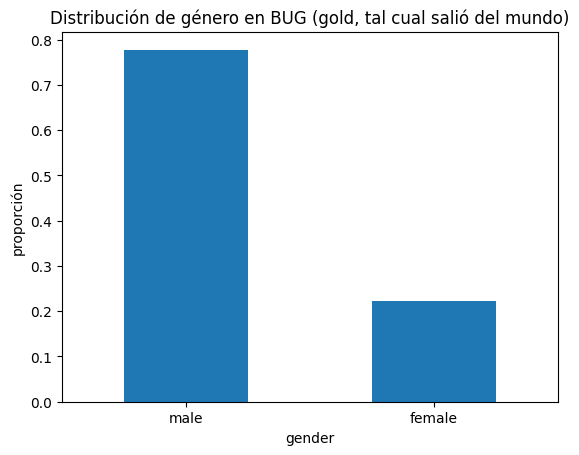

In [232]:
gold["gender"].value_counts(normalize=True).plot(
    kind="bar", title="Distribución de género en BUG (gold, tal cual salió del mundo)"
)
plt.ylabel("proporción")
plt.xticks(rotation=0)
plt.show()

Ya hay un desbalance marcado antes de que exista ningún modelo. La pregunta
interesante es otra: **¿ese desbalance es parejo entre profesiones, o hay
profesiones que "tiran" mucho más para un lado?**

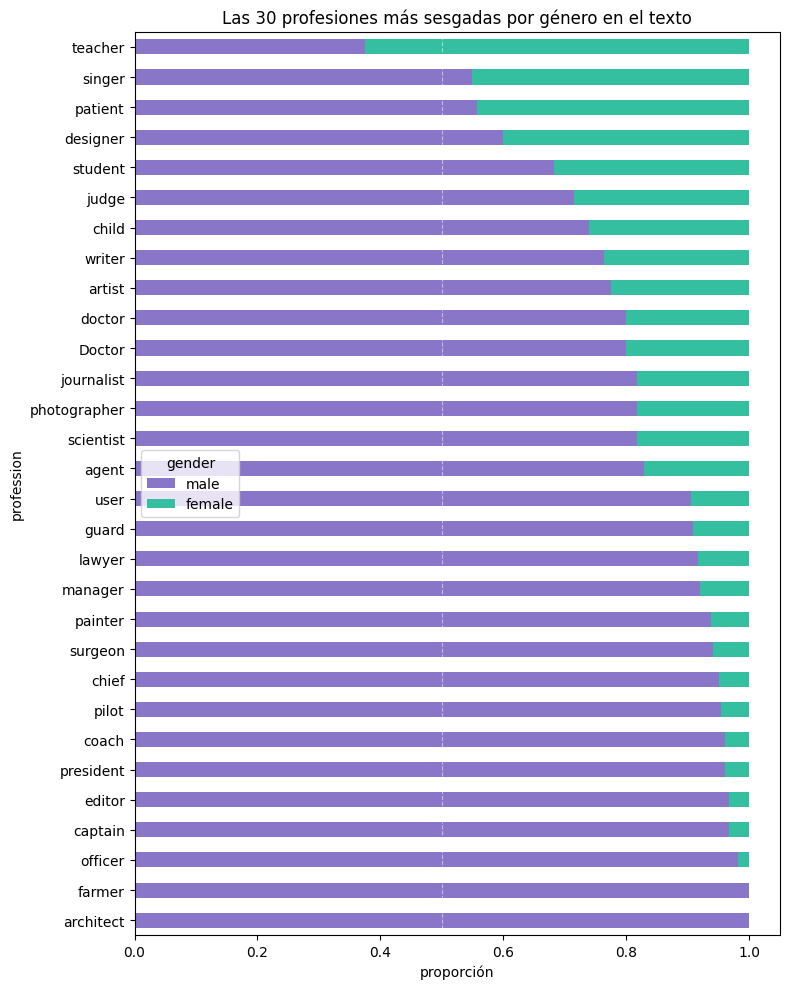

In [233]:
MIN_SUPPORT = 10  # ignoramos profesiones con muy pocos casos (son ruido, no señal)
prof_counts = gold["profession"].value_counts()
eligible = prof_counts[prof_counts >= MIN_SUPPORT].index
subset = gold[gold["profession"].isin(eligible)]
ct = pd.crosstab(subset["profession"], subset["gender"], normalize="index")

# no alcanza con mirar las profesiones más frecuentes: buscamos las más *sesgadas*
# (las 15 más asociadas a hombres + las 15 más asociadas a mujeres)
ct = ct.sort_values("female")
top_profs = pd.concat([ct.head(15), ct.tail(15)])[["male", "female"]]

top_profs.plot(kind="barh", stacked=True, figsize=(8, 10), color=["#8a76c9", "#33bfa0"])
plt.title("Las 30 profesiones más sesgadas por género en el texto")
plt.xlabel("proporción")
plt.axvline(0.5, color="white", linewidth=0.8, linestyle="--", alpha=0.5)
plt.legend(title="gender")
plt.tight_layout()
plt.show()

**Pará un segundo.** Antes de sacar cualquier conclusión de un gráfico como el de
arriba, hay que preguntarse: *¿las categorías están escritas siempre igual?* Miremos
el archivo **crudo** (`raw_gold`, sin pasar por `load_bug()`):

In [234]:
raw_gold[raw_gold["profession"].str.lower() == "doctor"]["profession"].value_counts()

profession
doctor    10
Doctor    10
Name: count, dtype: int64

`doctor` y `Doctor` son la misma profesión — una aparece a mitad de oración y la
otra al principio (con mayúscula por gramática, no por significado). Para pandas son
dos categorías distintas: sin darnos cuenta, **partimos a la mitad** el conteo real de
"doctor" en dos barras separadas. Y no es solo `doctor`: en `gold_BUG` esto le pasa a
27 profesiones distintas.

Por eso **normalizar viene antes que graficar**: `biaslab/data.py` ya hace
`profession.str.lower()` dentro de `load_bug()`, así que el gráfico de arriba ya está
limpio. Pero vale la pena verlo explícito una vez: la limpieza de datos no es un
detalle técnico, es lo que separa un análisis correcto de uno engañoso.

**Ejercicio rápido** — cambiá el nombre de la profesión de abajo (por
ejemplo `"nurse"`, `"engineer"`, `"teacher"`, `"officer"`) y mirá su
distribución de género:

In [236]:
profesion_a_mirar = "nurse"  # <- probá cambiar esto
gold[gold["profession"] == profesion_a_mirar]["gender"].value_counts()

gender
female    5
male      3
Name: count, dtype: int64

### Un vistazo a una variable numérica: `distance`

`distance` mide cuántas palabras hay entre la profesión y el pronombre que la
referencia (columna numérica de verdad, de las que vimos en el vocabulario inicial).
Cuatro formas típicas de resumir una variable numérica:

- **Media (promedio)**: sumar todo y dividir por la cantidad de casos. Le afectan
  mucho los valores extremos (*outliers*).
- **Mediana**: el valor del medio si ordenás todos los casos de menor a mayor. No le
  importan los extremos — es más "robusta".
- **Moda**: el valor que más se repite.
- **Percentil P**: el valor que deja a P% de los casos por debajo. Ej: percentil 90 =
  el valor que supera el 90% de los casos.

In [237]:
distance = raw_gold["distance"]

print("media   :", round(distance.mean(), 2))
print("mediana :", distance.median())
print("moda    :", distance.mode()[0])
print()
print("percentiles:")
print(distance.quantile([0.25, 0.5, 0.75, 0.90]))

media   : 8.36
mediana : 6.0
moda    : 2

percentiles:
0.25     3.0
0.50     6.0
0.75    11.0
0.90    17.0
Name: distance, dtype: float64


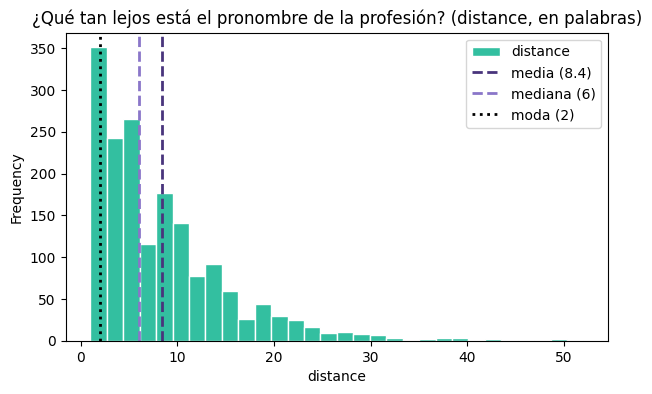

In [238]:
distance.plot(kind="hist", bins=30, color="#33bfa0", edgecolor="white", figsize=(7, 4))
plt.axvline(distance.mean(), color="#49347c", linestyle="--", linewidth=2, label=f"media ({distance.mean():.1f})")
plt.axvline(distance.median(), color="#8a76c9", linestyle="--", linewidth=2, label=f"mediana ({distance.median():.0f})")
plt.axvline(distance.mode()[0], color="black", linestyle=":", linewidth=2, label=f"moda ({distance.mode()[0]})")
plt.title("¿Qué tan lejos está el pronombre de la profesión? (distance, en palabras)")
plt.xlabel("distance")
plt.legend()
plt.show()

Media (8.36), mediana (6) y moda (2) dan **tres números distintos** — y no es un
error, es la forma de la distribución: la mayoría de los casos tiene el pronombre
bien cerca de la profesión (por eso la moda es baja), pero hay una cola de oraciones
donde está bastante más lejos. Esos pocos casos extremos tienen nombre:
**outliers** — valores que se alejan mucho del resto de los datos. Con que haya
unos pocos alcanza para **empujar la media hacia arriba**, aunque la mediana ni se
inmute (por eso es más &ldquo;robusta&rdquo; a los outliers que la media).

Guardá esta idea para más adelante: un solo número resumen (como el accuracy)
puede esconder la forma real de lo que está pasando — vamos a ver exactamente lo
mismo con los modelos en el Acto 3.

¿Cómo se ve un caso concreto? Miremos la fila 0 de `raw_gold`:

In [239]:
import ast

fila = raw_gold.iloc[0]
tokens = ast.literal_eval(fila["tokens"])

print("oración:      ", fila["sentence_text"])
print("profesión     :", f'"{tokens[fila["profession_first_index"]]}"', "(palabra n°", fila["profession_first_index"], ")")
print("pronombre     :", f'"{tokens[fila["g_first_index"]]}"', "(palabra n°", fila["g_first_index"], ")")
print("distance      :", fila["distance"], "=", fila["g_first_index"], "-", fila["profession_first_index"])

oración:       My friend , who grew up in Africa , explained that in his mental models , he does not assume that the government will provide protection or security .
profesión     : "friend" (palabra n° 1 )
pronombre     : "he" (palabra n° 16 )
distance      : 15 = 16 - 1


**Cierre del Acto 1:** el texto (el mundo) ya trae asociaciones entre
profesión y género antes de que entrenemos absolutamente nada. Ahora la
pregunta es qué hace un modelo con esa realidad.

---
## Acto 2 — El modelo

*Mismo texto, tres traductores distintos — y uno de ellos ni sabe inglés.*

Vamos a entrenar **tres formas distintas de representar el mismo texto**
para la misma tarea (predecir género a partir del contexto), y comparar.

Para entrenar usamos `balanced_BUG`: una versión de BUG armada por sus
autores para estar balanceada 50/50 en género **y** en congruencia con el
estereotipo (mitad de los casos siguen el estereotipo ocupacional, mitad lo
contradicen). Usamos una muestra de 6000 filas para que entrene rápido. Pero antes a jugar un poco con modelos.

### ¿De dónde sale un modelo &ldquo;pre-entrenado&rdquo;?

De [Hugging Face](https://huggingface.co/) &mdash; el repositorio más grande de
modelos open source: cualquiera puede subir un modelo entrenado y cualquiera
puede bajarlo gratis. `distilbert-base-uncased`, el modelo que usamos en este
taller, es literalmente esta página:
[huggingface.co/distilbert-base-uncased](https://huggingface.co/distilbert-base-uncased)

Cuando corremos `AutoModel.from_pretrained("distilbert-base-uncased")`, la
librería `transformers` baja de ahí los pesos entrenados, la configuración y
el tokenizer, y los deja **cacheados en el disco** para no volver a bajarlos.
`setup.sh` ya los bajó por vos (para no depender de la red durante la charla)
&mdash; veamos qué se bajó realmente:

In [240]:
from huggingface_hub import scan_cache_dir

cache = scan_cache_dir()
for repo in cache.repos:
    if repo.repo_id == "distilbert-base-uncased":
        print(f"{repo.repo_id} — {repo.size_on_disk_str} en disco\n")
        for rev in repo.revisions:
            print("carpeta local:", rev.snapshot_path)
            print()
            for f in sorted(rev.files, key=lambda f: f.file_name):
                print(f"  {f.file_name:<28} {f.size_on_disk_str}")

distilbert-base-uncased — 268.7M en disco

carpeta local: /Users/noeliaqualindi/.cache/huggingface/hub/models--distilbert-base-uncased/snapshots/12040accade4e8a0f71eabdb258fecc2e7e948be

  config.json                  483.0
  model.safetensors            268.0M
  tokenizer.json               466.1K
  tokenizer_config.json        48.0
  vocab.txt                    231.5K


Cuatro archivos, cuatro roles distintos:

- `config.json` &mdash; la arquitectura: cuántas capas, qué tamaño tienen, etc.
- `model.safetensors` &mdash; los pesos entrenados. Acá vive el &ldquo;conocimiento&rdquo;
  del modelo (268 MB de números).
- `tokenizer.json` / `vocab.txt` / `tokenizer_config.json` &mdash; el tokenizer
  (el mismo concepto de la slide &ldquo;¿qué es tokenizar?&rdquo;).

### Dos palabras que vas a escuchar todo el rato: peso y PyTorch

- **Peso (o parámetro)**: cada conexión de la red neuronal tiene un número
  asociado que se ajusta durante el entrenamiento. `model.safetensors` es,
  literalmente, la lista de esos números guardada en disco.
- **PyTorch** (el paquete `torch`): el motor matemático que hace el trabajo
  pesado por detrás — maneja los tensores (arreglos de números), calcula
  automáticamente las derivadas que hacen falta para entrenar (los
  *gradientes*), y decide si esas cuentas corren en CPU o GPU.
  `transformers` (Hugging Face) construye los modelos **arriba** de PyTorch:
  nos da arquitecturas ya armadas como DistilBERT, pero quien hace las
  cuentas, por debajo, es PyTorch.

**Otro dato importante: ¿hasta cuántos tokens puede recibir de una sola
vez?** Es decir, cuántos vectores de 768 puede procesar en un solo pase
&mdash; el &ldquo;contexto&rdquo; del que hablamos antes, ahora con el
número real. Está en el mismo `config.json`:

In [241]:
from transformers import AutoConfig

AutoConfig.from_pretrained("distilbert-base-uncased").max_position_embeddings

512

**512 tokens como máximo** &mdash; si le mandás una oración más larga,
hay que cortarla (por eso `truncation=True` en el tokenizer). En este
proyecto usamos `max_length=48` o `64` en vez de 512: nuestras oraciones de
`BUG` son cortas, y limitar el largo hace todo más rápido &mdash; pero es
una elección nuestra, no un límite del modelo.

Para comparar: GPT-3 soporta **2.048 tokens** de contexto (4&times; más) &mdash;
otro eje más en el que los modelos grandes escalan, además de dimensiones y
capas.

### Antes de entrenar nada: un modelo pre-entrenado vs. uno sin entrenar

Antes de meternos a entrenar clasificadores, juguemos un rato con
`distilbert-base-uncased` tal cual viene. Le tapamos el pronombre con su
token de máscara y le pedimos que lo complete. Comparamos dos versiones de
la **misma arquitectura**:

- **Pre-entrenado**: los pesos reales, aprendidos leyendo muchísimo texto en inglés.
- **Sin entrenar**: mismo tamaño, mismas capas, pero con los pesos inicializados
  al azar — nunca leyó una palabra.

In [242]:
from transformers import pipeline, AutoConfig, AutoModelForMaskedLM, AutoTokenizer

tokenizer_mlm = AutoTokenizer.from_pretrained("distilbert-base-uncased")

modelo_preentrenado = AutoModelForMaskedLM.from_pretrained("distilbert-base-uncased").eval()
fill_preentrenado = pipeline("fill-mask", model=modelo_preentrenado, tokenizer=tokenizer_mlm, device="mps")

config = AutoConfig.from_pretrained("distilbert-base-uncased")
modelo_sin_entrenar = AutoModelForMaskedLM.from_config(config).eval()
fill_sin_entrenar = pipeline("fill-mask", model=modelo_sin_entrenar, tokenizer=tokenizer_mlm, device="mps")
print("listo")

Device set to use mps
Device set to use mps


listo


In [243]:
n_params_pre = sum(p.numel() for p in modelo_preentrenado.parameters())
n_params_random = sum(p.numel() for p in modelo_sin_entrenar.parameters())
print(f"pre-entrenado : {n_params_pre:,} pesos")
print(f"sin entrenar  : {n_params_random:,} pesos")

pre-entrenado : 66,985,530 pesos
sin entrenar  : 66,985,530 pesos


Exactamente la misma cantidad de pesos: **66.985.530** en los dos. Es la
misma arquitectura — ni un peso más, ni uno menos. La única diferencia es el
**valor** de cada uno de esos números: en el pre-entrenado, cada peso se
ajustó leyendo muchísimo texto; en el otro, son números al azar que nunca se
tocaron. Eso es literalmente lo que significa &ldquo;entrenar&rdquo;:
encontrar los valores correctos para millones de pesos.

Probemos con oraciones que cambian solo la profesión:

In [244]:
MASK = tokenizer_mlm.mask_token
frases = [
    f"The nurse said {MASK} would return tomorrow.",
    f"The engineer said {MASK} would return tomorrow.",
    f"The ceo said {MASK} would return tomorrow.",
]


def top_predicciones(pipe, frase, k=5):
    return [(p["token_str"].strip(), round(p["score"], 3)) for p in pipe(frase, top_k=k)]


for frase in frases:
    print(frase)
    print("  pre-entrenado:", top_predicciones(fill_preentrenado, frase))
    print("  sin entrenar :", top_predicciones(fill_sin_entrenar, frase))
    print()

The nurse said [MASK] would return tomorrow.
  pre-entrenado: [('she', 0.079), ('he', 0.048), ('they', 0.025), ('i', 0.008), ('we', 0.008)]
  sin entrenar : [('keyboard', 0.0), ('gaped', 0.0), ('##gor', 0.0), ('locals', 0.0), ('rosa', 0.0)]

The engineer said [MASK] would return tomorrow.
  pre-entrenado: [('he', 0.095), ('they', 0.04), ('it', 0.02), ('she', 0.017), ('we', 0.011)]
  sin entrenar : [('keyboard', 0.0), ('gaped', 0.0), ('rosa', 0.0), ('locals', 0.0), ('##gor', 0.0)]

The ceo said [MASK] would return tomorrow.
  pre-entrenado: [('he', 0.071), ('they', 0.031), ('she', 0.021), ('it', 0.018), ('davis', 0.004)]
  sin entrenar : [('gaped', 0.0), ('keyboard', 0.0), ('rosa', 0.0), ('locals', 0.0), ('emancipation', 0.0)]



El modelo **sin entrenar** tira tokens al azar con probabilidad casi cero —
la arquitectura no sabe nada, nunca vio una palabra en inglés.

El **pre-entrenado** ya arma oraciones con sentido gramatical... y si te fijás
en las probabilidades, `she` pesa más que `he` para *nurse*, pero se invierte
para *engineer* y *ceo*. Y todavía no entrenamos absolutamente nada — ese
sesgo ya venía incorporado en el modelo pre-entrenado, aprendido del texto con
el que se entrenó originalmente.

### ¿Y si probamos con oraciones reales, del dataset que estamos usando hoy?

Las de arriba las escribimos nosotros. Probemos ahora con oraciones que salen
directo de `gold_BUG` — el mismo dataset que venimos mirando desde el Acto 1.
Elegimos casos con **un solo pronombre** y **poca distancia** a la profesión,
para que la oración sea corta y fácil de leer:

In [245]:
profesiones_interes = ["nurse", "doctor", "teacher", "farmer"]

for prof in profesiones_interes:
    candidatas = raw_gold[
        (raw_gold["profession"].str.lower() == prof)
        & (raw_gold["num_of_pronouns"] == 1)
        & (raw_gold["distance"] <= 6)
        & (raw_gold["sentence_text"].str.len() < 90)
    ]
    fila = candidatas.iloc[0]
    tokens = ast.literal_eval(fila["tokens"])
    tokens[fila["g_first_index"]] = tokenizer_mlm.mask_token
    frase_real = " ".join(tokens)

    print(f"[{prof}] {frase_real}")
    print("  pre-entrenado:", top_predicciones(fill_preentrenado, frase_real))
    print()

[nurse] Spike , nervously waiting , asks the nurse if [MASK] could see Sarah .
  pre-entrenado: [('she', 0.274), ('he', 0.2), ('anyone', 0.065), ('they', 0.062), ('sarah', 0.035)]

[doctor] Elodie / Ella was born in 1848 to an army doctor and [MASK] wife .
  pre-entrenado: [('his', 0.341), ('american', 0.026), ('first', 0.021), ('irish', 0.019), ('french', 0.017)]

[teacher] A high school physics teacher changed [MASK] life forever .
  pre-entrenado: [('his', 0.614), ('her', 0.237), ('my', 0.053), ('their', 0.035), ('your', 0.01)]

[farmer] The farmer gets [MASK] money right on the spot .
  pre-entrenado: [('his', 0.104), ('the', 0.092), ('some', 0.089), ('enough', 0.054), ('extra', 0.03)]



Mismo fenómeno, ahora con texto real y sin que nosotros hayamos elegido las
palabras: el modelo pre-entrenado ya trae asociaciones de género aprendidas,
antes de que nosotros entrenemos absolutamente nada.

---
## 🧪 BENCH 1 — Ejemplos sueltos (fill-mask, sin entrenar nada)

### ¿Existen modelos pre-entrenados pensados para tener *menos* sesgo?

Sí. Hay técnicas para tomar un modelo ya entrenado y ajustarlo específicamente
para reducir asociaciones de género (sin volver a entrenarlo desde cero).
Comparemos dos modelos reales de Hugging Face:

- **Vanilla**: `distilbert-base-cased`, tal cual sale del pre-entrenamiento normal.
- **&ldquo;Des-sesgado&rdquo;**: [`aieng-lab/distilbert-base-cased-gradiend-gender-debiased`](https://huggingface.co/aieng-lab/distilbert-base-cased-gradiend-gender-debiased),
  el mismo modelo, con una técnica (GRADIEND) aplicada específicamente para
  reducir sesgo de género.

In [246]:
from transformers import AutoModel

tokenizer_vanilla = AutoTokenizer.from_pretrained("distilbert-base-cased")
modelo_vanilla_mlm = AutoModelForMaskedLM.from_pretrained("distilbert-base-cased").eval()
fill_vanilla = pipeline("fill-mask", model=modelo_vanilla_mlm, tokenizer=tokenizer_vanilla, device="mps")

tokenizer_debiased = AutoTokenizer.from_pretrained("aieng-lab/distilbert-base-cased-gradiend-gender-debiased")
modelo_debiased_mlm = AutoModelForMaskedLM.from_pretrained(
    "aieng-lab/distilbert-base-cased-gradiend-gender-debiased"
).eval()
fill_debiased = pipeline("fill-mask", model=modelo_debiased_mlm, tokenizer=tokenizer_debiased, device="mps")

frases_cased = [
    "The nurse said [MASK] would return tomorrow.",
    "The engineer said [MASK] would return tomorrow.",
    "The CEO said [MASK] would return tomorrow.",
]
for frase in frases_cased:
    print(frase)
    print("  vanilla     :", top_predicciones(fill_vanilla, frase))
    print("  des-sesgado :", top_predicciones(fill_debiased, frase))
    print()

Device set to use mps
Device set to use mps


The nurse said [MASK] would return tomorrow.
  vanilla     : [('she', 0.298), ('he', 0.195), ('they', 0.158), ('it', 0.015), ('we', 0.014)]
  des-sesgado : [('she', 0.393), ('they', 0.145), ('he', 0.132), ('we', 0.013), ('it', 0.013)]

The engineer said [MASK] would return tomorrow.
  vanilla     : [('he', 0.184), ('they', 0.171), ('it', 0.072), ('she', 0.048), ('we', 0.008)]
  des-sesgado : [('they', 0.17), ('he', 0.143), ('she', 0.084), ('it', 0.07), ('we', 0.008)]

The CEO said [MASK] would return tomorrow.
  vanilla     : [('he', 0.208), ('they', 0.144), ('she', 0.084), ('it', 0.028), ('we', 0.013)]
  des-sesgado : [('he', 0.158), ('they', 0.14), ('she', 0.14), ('it', 0.027), ('we', 0.012)]



El des-sesgo **no es parejo**: para *engineer* y *CEO* la brecha entre
&ldquo;he&rdquo; y &ldquo;she&rdquo; se achica bastante. Pero para *nurse*
pasa lo contrario — la brecha entre &ldquo;she&rdquo; y &ldquo;he&rdquo; se
agranda. Ajustar un modelo para un tipo de sesgo no garantiza arreglar todos
los casos por igual.

---
## 🧪 BENCH 2 — Clasificador entrenado (Logistic Regression)

### Benchmark con nuestro propio dataset

Un par de ejemplos sueltos no alcanza (ya lo dijimos en el Acto 3). Antes de
balancear nada ni entrenar los modelos "oficiales" del taller, hagamos un
mini-benchmark: usamos cada encoder (vanilla y des-sesgado) para sacar
embeddings de `gold` — tal cual, con su desbalance real — entrenamos una
regresión logística arriba de cada uno, y medimos con `slice_report`:

**¿Qué es una regresión logística, y por qué hace falta entrenar algo?**

Un embedding (el vector de 768 números que sale del encoder) no trae ninguna
noción de &ldquo;male&rdquo;/&ldquo;female&rdquo; incorporada — son solo
números que representan significado. Para convertir ese vector en una
decisión de clase, hace falta *algo* que aprenda a mapear esos números a una
etiqueta.

La regresión logística es la opción más simple: matemáticamente es **una
sola capa lineal** (multiplica el vector por unos pesos, suma un sesgo) +
una función sigmoide que convierte el resultado en una probabilidad entre 0
y 1. Sin capas ocultas.

<small>(Para comparar: la cabeza que arma Hugging Face para
`AutoModelForSequenceClassification` — la que usamos en el fine-tuning más
adelante — tiene **2 capas**: `pre_classifier` (768&rarr;768, con una
activación) + `classifier` (768&rarr;2). Un poco más compleja, pero sigue
siendo chica comparada con el resto del modelo.)</small>

Y acá está el punto flaco de este benchmark en particular: el encoder
pre-entrenado **no trae** una cabeza lista para nuestra tarea (a diferencia
del `fill-mask` de arriba, que sí la trae) — así que tenemos que entrenar
una nosotros, y esa regresión logística aprende de **nuestros** datos, con
**nuestro** desbalance. Por eso este resultado y el del `fill-mask` de
arriba van a contar historias distintas.

**¿Dónde más aparece una función no lineal como la sigmoide?** En más
lugares de los que parece — es lo que hace que apilar capas sirva de algo:

| Dónde | Función | Para qué |
|---|---|---|
| Regresión logística (nuestro clasificador) | **Sigmoide** | Convierte la combinación lineal (`Wx + b`) en una probabilidad entre 0 y 1 |
| Atención (dentro de cada capa) | **Softmax** | Convierte los puntajes de atención en pesos que suman 1 |
| FFN de cada capa del Transformer (`768→3072→768`) | **GELU** | Entre las dos capas lineales de la red feed-forward |
| Cabeza de clasificación (fine-tuning, `pre_classifier→classifier`) | **ReLU** | Entre las dos capas lineales de la cabeza |

La regla general: la función de activación se usa SIEMPRE justo después de multiplicar por una matriz de pesos (una capa lineal), antes de que ese resultado siga a cualquier otro lado.

Sin una función no lineal en el medio, **no importa cuántas capas apiles**:
matemáticamente, una cadena de transformaciones lineales siempre colapsa en
una sola — nuestras &ldquo;6 capas&rdquo; valdrían lo mismo que 1. La no
linealidad es lo que le permite a la red aprender relaciones curvas,
umbrales y combinaciones tipo &ldquo;esto Y aquello, pero solo si&rdquo;
— algo que una sola línea recta no puede separar.

In [247]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from biaslab.features import embed_texts

gold_train, gold_test = train_test_split(
    gold, test_size=0.2, random_state=42, stratify=gold["label"]
)


def cargar_encoder(nombre):
    tok = AutoTokenizer.from_pretrained(nombre)
    enc = AutoModel.from_pretrained(nombre).eval()
    return tok, enc


tok_v, enc_v = cargar_encoder("distilbert-base-cased")
tok_d, enc_d = cargar_encoder("aieng-lab/distilbert-base-cased-gradiend-gender-debiased")

emb_train_vanilla = embed_texts(gold_train["text"].tolist(), tok_v, enc_v)
emb_test_vanilla = embed_texts(gold_test["text"].tolist(), tok_v, enc_v)
emb_train_debiased = embed_texts(gold_train["text"].tolist(), tok_d, enc_d)
emb_test_debiased = embed_texts(gold_test["text"].tolist(), tok_d, enc_d)

modelo_vanilla_lr = LogisticRegression(max_iter=1000).fit(emb_train_vanilla, gold_train["label"])
modelo_debiased_lr = LogisticRegression(max_iter=1000).fit(emb_train_debiased, gold_train["label"])

gold_test = gold_test.copy()
gold_test["pred_vanilla"] = modelo_vanilla_lr.predict(emb_test_vanilla)
gold_test["pred_debiased"] = modelo_debiased_lr.predict(emb_test_debiased)

print("=== vanilla ===")
display(slice_report(gold_test, "label", "pred_vanilla"))
print("\n=== des-sesgado ===")
display(slice_report(gold_test, "label", "pred_debiased"))

=== vanilla ===


,n,accuracy,f1_macro
corte,,,
overall,344.0,0.788,0.619
gender=female,77.0,0.273,0.214
gender=male,267.0,0.936,0.484
stereotype (congruente),175.0,0.863,0.587
anti-stereotype (incongruente),87.0,0.724,0.540
Δ gender (|male - female|),NaN,0.664,NaN
Δ stereotype,NaN,0.139,NaN



=== des-sesgado ===


,n,accuracy,f1_macro
corte,,,
overall,344.0,0.791,0.627
gender=female,77.0,0.286,0.222
gender=male,267.0,0.936,0.484
stereotype (congruente),175.0,0.869,0.615
anti-stereotype (incongruente),87.0,0.724,0.540
Δ gender (|male - female|),NaN,0.651,NaN
Δ stereotype,NaN,0.144,NaN


**Antes de leer las tablas, dos columnas que van a aparecer todo el
rato:**

- **`accuracy`**: De todos los casos, ¿en qué porcentaje
  acertó? Fácil de entender, pero engañoso cuando las clases están
  desbalanceadas: un modelo que siempre dice &ldquo;male&rdquo; puede tener
  accuracy alto solo porque la mayoría de los casos SON male.
- **`f1_macro`**: combina dos cosas por clase, **precision** (de las veces
  que dijo &ldquo;female&rdquo;, ¿cuántas realmente lo eran?) y **recall**
  (de las que realmente eran &ldquo;female&rdquo;, ¿cuántas detectó?) — en
  un solo número. Lo calcula **por separado para cada clase y después
  promedia** (por eso &ldquo;macro&rdquo;), dándole el mismo peso a la
  clase minoritaria que a la mayoritaria. Por eso puede bajar mucho aunque
  el accuracy se mantenga alto, es exactamente el tipo de cosa de que hablar y observar en esta charla.

**Y las filas `Δ gender` / `Δ stereotype` van a salir con `NaN` en `n` y `f1_macro` — es esperable, no un error.** Esas dos filas no son un subconjunto real de datos (no tienen su propio `n` de casos): son la *resta* entre dos filas de arriba, y esa resta solo tiene sentido para `accuracy`. `NaN` ahí significa &ldquo;no aplica&rdquo;, no que algo haya fallado.

¿Qué está pasando en detalle? Miremos la matriz de confusión de cada uno
sobre `gold_test` (sirve perfecto acá: es una foto del test, no hace falta
un conjunto de *validation* aparte — ese solo hace falta cuando estás
comparando/ajustando configuraciones, y acá entrenamos una sola vez con
valores por defecto):

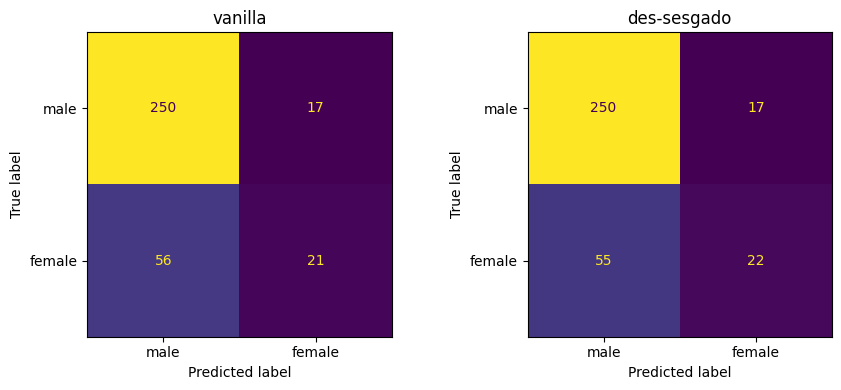

In [248]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
ConfusionMatrixDisplay.from_predictions(
    gold_test["label"], gold_test["pred_vanilla"],
    display_labels=["male", "female"], ax=axes[0], colorbar=False,
)
axes[0].set_title("vanilla")
ConfusionMatrixDisplay.from_predictions(
    gold_test["label"], gold_test["pred_debiased"],
    display_labels=["male", "female"], ax=axes[1], colorbar=False,
)
axes[1].set_title("des-sesgado")
plt.tight_layout()
plt.show()

Casi idénticas entre los dos modelos: de los ~77 casos *female* del test,
ambos aciertan apenas 20-21 y confunden 56-57 como *male*. De los ~267 casos
*male*, aciertan 250 en los dos. El &ldquo;des-sesgo&rdquo; del encoder no
alcanzó a mover esta matriz — otra forma de ver el mismo `Δ gender` de
arriba, pero mirando los errores caso por caso en vez de un resumen.

**Esto es lo importante:** `Δ gender` prácticamente no se mueve (~.68 →
~.66) entre el modelo vanilla y el "des-sesgado" — aunque en los ejemplos de
arriba sí vimos una diferencia real en el `fill-mask`. ¿Por qué?

Acá entrenamos con `gold` **tal cual**, con su desbalance real (78% male /
22% female) — el mismo problema del Acto 1. Un encoder mejor no arregla un
dataset de entrenamiento desbalanceado: el sesgo de los *datos* pesa más que
el sesgo (o la falta de sesgo) del *modelo pre-entrenado*. Es la primera
señal del Acto 4, adelantada: no alcanza con elegir un mejor modelo si el
dato de entrenamiento sigue estando sesgado.

---
## 🧪 BENCH 3 — Fill-mask generalizado, sin entrenar nada

### ¿Y sin entrenar ningún clasificador?

El benchmark de arriba entrena una regresión logística **nuestra**, con
**nuestros** datos desbalanceados — así que el desbalance de `gold` puede
estar tapando la diferencia real entre los dos encoders. Midamos el sesgo
**sin entrenar nada**, usando el propio `fill-mask` como predictor directo:
para cada oración, le preguntamos al modelo si el pronombre masculino o el
femenino encaja mejor, y comparamos contra la etiqueta real.

Para que la pregunta sea gramaticalmente válida, el pronombre
&ldquo;contrario&rdquo; tiene que tener el mismo caso: `he`&harr;`she`,
`him`&harr;`her`, `his`&harr;`her`, `himself`&harr;`herself`. Dejamos afuera
únicamente los casos donde el pronombre real es `her` (221 de 1.717): es
ambiguo — puede ser objeto (&ldquo;asked her&rdquo; &rarr; contrario `him`)
o posesivo (&ldquo;her wife&rdquo; &rarr; contrario `his`), y no hay forma
de distinguirlos con las columnas que tenemos. Con el resto cubrimos
**1.496 de 1.717 oraciones (87%) de `gold`**, casi todo el dataset, sin
entrenar un solo peso:

In [249]:
PARES_DE_PRONOMBRE = {
    "he": ("he", "she"),
    "she": ("he", "she"),
    "him": ("him", "her"),
    "his": ("his", "her"),
    "himself": ("himself", "herself"),
    "herself": ("himself", "herself"),
}

candidatas = raw_gold[raw_gold["g"].str.lower().isin(PARES_DE_PRONOMBRE)].copy()
candidatas["gender"] = candidatas["predicted gender"].str.lower()
candidatas = candidatas[candidatas["gender"].isin(["male", "female"])]
candidatas["label"] = candidatas["gender"].map({"male": 0, "female": 1})
print(f"{len(candidatas)} de {len(raw_gold)} oraciones cubiertas ({len(candidatas) / len(raw_gold):.0%})")

masked_textos, target_pares = [], []
for _, fila in candidatas.iterrows():
    tokens = ast.literal_eval(fila["tokens"])
    tokens[fila["g_first_index"]] = tokenizer_vanilla.mask_token
    masked_textos.append(" ".join(tokens))
    target_pares.append(PARES_DE_PRONOMBRE[fila["g"].lower()])
candidatas["masked"] = masked_textos
candidatas["target_par"] = target_pares

1496 de 1717 oraciones cubiertas (87%)


In [250]:
def prediccion_zero_shot(fill_pipe, df):
    resultados = {}
    for par, grupo in df.groupby("target_par"):
        masculino, femenino = par
        salidas = fill_pipe(grupo["masked"].tolist(), targets=[masculino, femenino])
        for idx, salida in zip(grupo.index, salidas):
            puntajes = {s["token_str"]: s["score"] for s in salida}
            resultados[idx] = 1 if puntajes.get(femenino, 0) > puntajes.get(masculino, 0) else 0
    return df.index.map(resultados)


candidatas["pred_vanilla_zeroshot"] = prediccion_zero_shot(fill_vanilla, candidatas)
candidatas["pred_debiased_zeroshot"] = prediccion_zero_shot(fill_debiased, candidatas)

print("=== vanilla (zero-shot, sin entrenar) ===")
display(slice_report(candidatas, "label", "pred_vanilla_zeroshot"))
print("\n=== des-sesgado (zero-shot, sin entrenar) ===")
display(slice_report(candidatas, "label", "pred_debiased_zeroshot"))

=== vanilla (zero-shot, sin entrenar) ===


,n,accuracy,f1_macro
corte,,,
overall,1496.0,0.888,0.737
gender=female,161.0,0.609,0.378
gender=male,1335.0,0.921,0.480
stereotype (congruente),807.0,0.938,0.728
anti-stereotype (incongruente),350.0,0.917,0.817
Δ gender (|male - female|),NaN,0.313,NaN
Δ stereotype,NaN,0.021,NaN



=== des-sesgado (zero-shot, sin entrenar) ===


,n,accuracy,f1_macro
corte,,,
overall,1496.0,0.794,0.665
gender=female,161.0,0.807,0.447
gender=male,1335.0,0.793,0.442
stereotype (congruente),807.0,0.866,0.617
anti-stereotype (incongruente),350.0,0.826,0.720
Δ gender (|male - female|),NaN,0.015,NaN
Δ stereotype,NaN,0.040,NaN


Misma idea que antes: miremos la matriz de confusión de cada uno, ahora sobre el 87% de `gold` (sin entrenar nada):

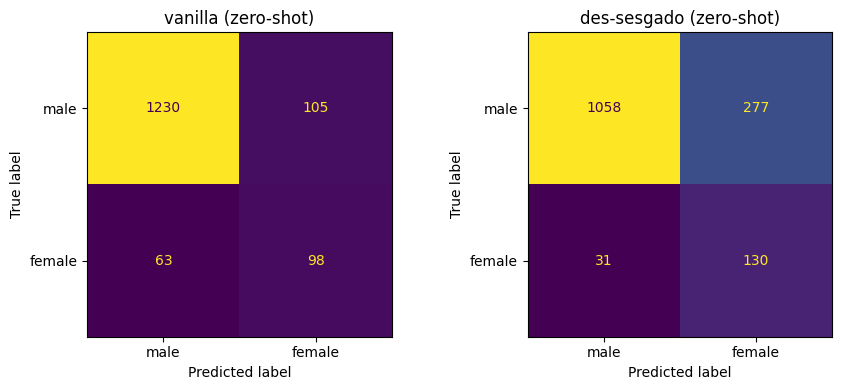

In [251]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
ConfusionMatrixDisplay.from_predictions(
    candidatas["label"], candidatas["pred_vanilla_zeroshot"],
    display_labels=["male", "female"], ax=axes[0], colorbar=False,
)
axes[0].set_title("vanilla (zero-shot)")
ConfusionMatrixDisplay.from_predictions(
    candidatas["label"], candidatas["pred_debiased_zeroshot"],
    display_labels=["male", "female"], ax=axes[1], colorbar=False,
)
axes[1].set_title("des-sesgado (zero-shot)")
plt.tight_layout()
plt.show()

Ahora sí se nota la diferencia caso por caso: en **vanilla**, de los casos
*female*, la mayoría se confunden como *male*. En el **des-sesgado**, los
aciertos quedan mucho más parejos entre las dos filas — coherente con el
`Δ gender` de .015 que vimos arriba. Compará esta matriz con la del
benchmark entrenado (más arriba): ahí las dos matrices eran casi idénticas
entre sí; acá son claramente distintas.

Con el 87% de `gold` cubierto y sin entrenar ni un peso, la diferencia es
todavía más marcada que con el subconjunto chico de antes: `Δ gender` pasa
de **.313** (vanilla) a **.015** (des-sesgado) — prácticamente desaparece
(92.1% vs 60.9% en vanilla; 79.3% vs 80.7% en des-sesgado, casi empatado).
El precio: el accuracy general baja un poco (de .888 a .794).

**Comparemos las dos formas de medir el mismo par de modelos:**

| | Δ gender **con** clasificador entrenado | Δ gender **sin** entrenar (zero-shot, 87% de gold) |
|---|---|---|
| vanilla | .677 | .313 |
| des-sesgado | .664 | .015 |

El des-sesgo **sí funciona**, y bastante bien, cuando lo medimos directo
sobre el modelo en casi todo el dataset. Pero en cuanto le entrenamos
encima un clasificador con datos desbalanceados, ese efecto se diluye casi
por completo. Moraleja: **cómo medís el sesgo importa tanto como qué
modelo elegís** — un benchmark zero-shot y un benchmark con clasificador
entrenado pueden contar historias distintas sobre el mismo modelo.

**Próximo paso:** dejamos de lado el modelo &ldquo;pelado&rdquo; y usamos sus
representaciones (embeddings) como insumo para entrenar clasificadores de
verdad, esta vez con un dataset **balanceado** a propósito. Volvemos a los
tres modelos del Acto 2 — arrancando por el más simple, que ni siquiera
necesita un Transformer.

## Balanceando los datos

In [252]:
balanced = load_bug(DATA_DIR / "bug" / "balanced_BUG_sample.csv")
print(f"{len(balanced)} oraciones — balance de género:")
print(balanced["gender"].value_counts(normalize=True))
print("balance de estereotipo (1=congruente, -1=incongruente):")
print(balanced["stereotype"].value_counts(normalize=True))

6000 oraciones — balance de género:
gender
female    0.501
male      0.499
Name: proportion, dtype: float64
balance de estereotipo (1=congruente, -1=incongruente):
stereotype
-1    0.501
 1    0.499
Name: proportion, dtype: float64


Así se ve el enmascarado (tapamos la profesión y el pronombre):

In [253]:
ejemplo = balanced.iloc[0]
print("ANTES:  ", ejemplo["original"])
print("DESPUÉS:", ejemplo["text"])

ANTES:   The artist accompanying Ottheinrich can only have made sketches during the journey , which he converted later to our plates in the size of up to 76 cm in width .
DESPUÉS: The [PERSON] accompanying Ottheinrich can only have made sketches during the journey , which [PRONOUN] converted later to our plates in the size of up to 76 cm in width .


In [214]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    balanced, test_size=0.2, random_state=42, stratify=balanced["label"]
)
print(f"train: {len(train_df)} — test: {len(test_df)}")

train: 4800 — test: 1200


### Modelo 1 — TF-IDF + Logistic Regression

Este modelo **no sabe inglés**. No sabe qué significa *engineer* ni *nurse*.
Solo cuenta palabras y aprende qué combinaciones se asociaron con cada
etiqueta en nuestros datos.

**¿Qué es TF-IDF?** Term Frequency &mdash; Inverse Document Frequency. Le da a
cada palabra un puntaje combinando dos cosas:

- **TF (frecuencia en el texto)**: cuántas veces aparece esa palabra en *esta* oración. Más repeticiones, más puntaje.
- **IDF (rareza en el dataset)**: qué tan poco común es esa palabra en *todas* las oraciones. Palabras como &ldquo;the&rdquo; o &ldquo;a&rdquo; aparecen en todos lados &rarr; puntaje bajo (no distinguen nada). Palabras raras/específicas &rarr; puntaje alto.

El resultado es un vector por oración con un número por cada palabra del vocabulario (acá, hasta `max_features=8000` palabras/pares de palabras, con `ngram_range=(1, 2)`) &mdash; la mayoría en cero, salvo las palabras que realmente aparecen en esa oración. Es un vector **enorme y disperso**, muy distinto del embedding de 768 números densos que vimos antes: acá cada posición del vector significa literalmente una palabra puntual, no un &ldquo;eje de significado&rdquo; aprendido.

In [215]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(train_df["text"])  # texto -> matriz dispersa [n_oraciones x n_palabras]: esto es lo que "entra" al modelo
X_test_tfidf = tfidf.transform(test_df["text"])

model_tfidf = LogisticRegression(max_iter=1000)
model_tfidf.fit(X_train_tfidf, train_df["label"])  # label: 0=male / 1=female -> clasificación BINARIA, un solo label por oración (no multi-label)
print("listo")

listo


¿Qué palabras aprendió a asociar con cada género?

In [216]:
feature_names = np.array(tfidf.get_feature_names_out())
coefs = model_tfidf.coef_[0]  # + empuja hacia female, - empuja hacia male (label 1=female)
orden = np.argsort(coefs)
print("Palabras que más empujan hacia MALE: ", list(feature_names[orden[:15]]))
print("Palabras que más empujan hacia FEMALE:", list(feature_names[orden[-15:]]))

Palabras que más empujan hacia MALE:  ['wife', 'the', 'pronoun wife', 'in pronoun', 'of the', 'season', 'management', 'is the', 'of', 'man', 'must', 'there', 'very', 'head person', 'john']
Palabras que más empujan hacia FEMALE: ['pop', 'sister', 'song', 'marriage', 'that pronoun', 'pronoun or', 'mother', 'women', 'nursing', 'children', 'woman', 'pronoun', 'pronoun husband', 'husband', 'female']


### Modelo 2 — Embeddings pre-entrenados (congelados)

Ahora usamos `distilbert-base-uncased`: un Transformer que ya sabe inglés
porque fue pre-entrenado en muchísimo texto. No lo tocamos (está
**congelado**), solo lo usamos para convertir cada oración en un vector.
Los vectores ya están precalculados por `setup.sh` para que esto sea
instantáneo.

In [217]:
emb_balanced = np.load(CACHE_DIR / "embeddings_balanced.npz")["vectors"]  # [n_oraciones x 768]: un vector por oración (en vez de texto), eso entra al modelo
# el orden de este array coincide con el de `balanced` (ver biaslab/data.py + scripts/precompute.py)
X_train_emb = emb_balanced[train_df.index]
X_test_emb = emb_balanced[test_df.index]

model_emb = LogisticRegression(max_iter=1000)
model_emb.fit(X_train_emb, train_df["label"])
print("listo")

listo


> La arquitectura define qué **puede** aprender un modelo. Pero la
> soberanía real &mdash; a quién termina respondiendo ese modelo &mdash;
> la tienen los datos con los que lo entrenamos. **Goberná los datos, y
> vas a gobernar el comportamiento.**

Con eso en mente, vamos a tocar los pesos de verdad por primera vez.

### Modelo 3 — Fine-tuning

*Le descongelamos un par de capas y lo mandamos al gimnasio — todo lo demás se queda mirando.*

Un paso más: además de usar la representación pre-entrenada, dejamos que
las **últimas capas** del Transformer se ajusten a nuestros datos. El resto
del modelo queda congelado.

```
DistilBERT
Layer 1   🔒
Layer 2   🔒
Layer 3   🔒
Layer 4   🔒
Layer 5   🔥  <- se entrena
Layer 6   🔥  <- se entrena
Classifier 🔥  <- se entrena
```

Entrenamos con una muestra chica (para que entre en el tiempo de la
charla). Si tu compu es lenta, bajá `SUBSET_SIZE`.

**¿&ldquo;Capas&rdquo; y &ldquo;dimensiones&rdquo; son lo mismo?** No —
son dos ejes distintos:

- **Dimensiones (768)**: cuántos números tiene **un** vector en un momento
  dado. El &ldquo;ancho&rdquo;.
- **Capas (6)**: cuántos pasos de procesamiento **secuenciales** atraviesa
  ese vector. La &ldquo;profundidad&rdquo;.

Un vector no tiene capas adentro — el mismo vector se va **transformando**
capa por capa, y cada capa devuelve un vector del mismo tamaño (768), nunca
más grande:

```
[768 números]  (embedding inicial)
     ↓ capa 1
[768 números]  (ya "vio" un poco de contexto)
     ↓ capa 2
[768 números]  (más contexto)
     ↓ ...
     ↓ capa 6
[768 números]  (versión final — esto es lo que devuelve last_hidden_state)
```

Las versiones intermedias (después de la capa 1, 2, 3&hellip;) existen
durante el cálculo, pero normalmente no las guardamos ni las miramos — solo
usamos la final.

**Por dentro, cada capa no se queda en 768 todo el tiempo.** Tiene dos
partes, con distinta cantidad de neuronas cada una:

- **Atención**: 4 capas lineales (`q_lin`, `k_lin`, `v_lin`, `out_lin`),
  todas 768&rarr;768.
- **FFN (feed-forward)**: 2 capas lineales, pero la primera **expande** el
  vector a 3072 neuronas (`lin1`: 768&rarr;3072), y la segunda lo **vuelve
  a comprimir** a 768 (`lin2`: 3072&rarr;768) antes de pasarlo a la
  siguiente capa.

**¿Qué determina que se infle justo a 3072?** No es algo que el modelo
decide sobre la marcha — es un **hiperparámetro fijo**, elegido por quienes
diseñaron la arquitectura, guardado en el mismo `config.json` que ya
miramos (`hidden_dim`). Mecánicamente, &ldquo;inflar&rdquo; es solo
multiplicar por una matriz de pesos que tiene 3072 columnas — no hay magia,
es el tamaño que esa matriz tiene porque así se construyó el modelo, antes
de entrenar un solo peso.

In [ ]:
AutoConfig.from_pretrained("distilbert-base-uncased").hidden_dim, AutoConfig.from_pretrained("distilbert-base-uncased").dim

**3072 = 768 &times; 4.** No es casualidad: expandir el vector a **4 veces**
su tamaño en el medio de cada capa es una convención de diseño que viene
del paper original del Transformer (2017) y que la mayoría de los modelos
copian (incluido GPT-3). La idea intuitiva: ese espacio extra le da a la
capa más &ldquo;lugar&rdquo; para combinar features de formas más
complejas antes de comprimir el resultado de vuelta al tamaño &ldquo;de
comunicación&rdquo; (768) que el resto de la red espera.

In [218]:
import torch
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SUBSET_SIZE = 1200  # bajalo a 500 si tu compu es lenta
EPOCHS = 1

ft_train = train_df.sample(n=min(SUBSET_SIZE, len(train_df)), random_state=0)

tokenizer_ft = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model_ft = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=2  # 2 salidas (logits), una por clase. Single-label: cada oración tiene UN solo género posible, no multi-label
)

for param in model_ft.distilbert.parameters():
    param.requires_grad = False
for layer in model_ft.distilbert.transformer.layer[-2:]:
    for param in layer.parameters():
        param.requires_grad = True

model_ft.to(DEVICE)
print("parámetros entrenables:", sum(p.numel() for p in model_ft.parameters() if p.requires_grad))

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


parámetros entrenables: 14767874


In [219]:
class TextDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = list(texts)
        self.labels = list(labels)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, i):
        return self.texts[i], self.labels[i]


def collate(batch):
    texts, labels = zip(*batch)
    # el tokenizer convierte texto en números: input_ids + attention_mask, cada uno [batch_size x seq_len] -> así "entra" el texto al modelo
    enc = tokenizer_ft(list(texts), padding=True, truncation=True, max_length=48, return_tensors="pt")
    enc["labels"] = torch.tensor(labels)
    return enc


loader = DataLoader(
    TextDataset(ft_train["text"], ft_train["label"]),
    batch_size=16,
    shuffle=True,
    collate_fn=collate,
)
optimizer = torch.optim.AdamW(
    [p for p in model_ft.parameters() if p.requires_grad], lr=2e-5
)

model_ft.train()
for epoch in range(EPOCHS):
    total_loss = 0.0
    for batch in loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        optimizer.zero_grad()
        out = model_ft(**batch)  # out.logits: [batch_size x 2] (un puntaje por clase); out.loss ya compara esos logits contra los labels reales
        out.loss.backward()
        optimizer.step()
        total_loss += out.loss.item()
    print(f"epoch {epoch + 1}/{EPOCHS} — loss promedio: {total_loss / len(loader):.4f}")

epoch 1/1 — loss promedio: 0.6796


In [220]:
@torch.no_grad()
def predict_finetuned(texts, batch_size=32):
    model_ft.eval()
    preds = []
    for start in range(0, len(texts), batch_size):
        batch = list(texts[start : start + batch_size])
        enc = tokenizer_ft(batch, padding=True, truncation=True, max_length=48, return_tensors="pt")
        enc = {k: v.to(DEVICE) for k, v in enc.items()}
        logits = model_ft(**enc).logits  # [batch_size x 2]: un logit por clase (male/female)
        preds.extend(logits.argmax(dim=-1).cpu().tolist())  # nos quedamos con la clase de mayor logit (single-label: una sola clase gana)
    return preds

---
## Acto 3 — Benchmark

*Con ustedes&hellip; el momento de la verdad (redoble de tambores no incluido).*

No alcanza con un accuracy global. Cortamos el resultado por género y por
congruencia con el estereotipo.

In [221]:
test_df = test_df.copy()
test_df["pred_tfidf"] = model_tfidf.predict(X_test_tfidf)
test_df["pred_emb"] = model_emb.predict(X_test_emb)
test_df["pred_ft"] = predict_finetuned(test_df["text"].tolist())

for col in ["pred_tfidf", "pred_emb", "pred_ft"]:
    print(f"\n=== {col} (test interno) ===")
    display(slice_report(test_df, "label", col))


=== pred_tfidf (test interno) ===


,n,accuracy,f1_macro
corte,,,
overall,1200.0,0.644,0.644
gender=female,601.0,0.656,0.396
gender=male,599.0,0.633,0.388
stereotype (congruente),603.0,0.633,0.633
anti-stereotype (incongruente),597.0,0.655,0.655
Δ gender (|male - female|),NaN,0.023,NaN
Δ stereotype,NaN,0.021,NaN



=== pred_emb (test interno) ===


,n,accuracy,f1_macro
corte,,,
overall,1200.0,0.728,0.727
gender=female,601.0,0.742,0.426
gender=male,599.0,0.713,0.416
stereotype (congruente),603.0,0.711,0.711
anti-stereotype (incongruente),597.0,0.744,0.744
Δ gender (|male - female|),NaN,0.029,NaN
Δ stereotype,NaN,0.032,NaN



=== pred_ft (test interno) ===


,n,accuracy,f1_macro
corte,,,
overall,1200.0,0.670,0.662
gender=female,601.0,0.519,0.342
gender=male,599.0,0.821,0.451
stereotype (congruente),603.0,0.630,0.620
anti-stereotype (incongruente),597.0,0.710,0.705
Δ gender (|male - female|),NaN,0.302,NaN
Δ stereotype,NaN,0.080,NaN


Ahora lo mismo pero contra `gold_BUG`: el dataset **real, desbalanceado**
(no el balanceado con el que entrenamos). Es más parecido a "el mundo".

In [222]:
emb_gold = np.load(CACHE_DIR / "embeddings_gold.npz")["vectors"]

gold = gold.copy()
gold["pred_tfidf"] = model_tfidf.predict(tfidf.transform(gold["text"]))
gold["pred_emb"] = model_emb.predict(emb_gold)
gold["pred_ft"] = predict_finetuned(gold["text"].tolist())

for col in ["pred_tfidf", "pred_emb", "pred_ft"]:
    print(f"\n=== {col} (gold, mundo real) ===")
    display(slice_report(gold, "label", col))


=== pred_tfidf (gold, mundo real) ===


,n,accuracy,f1_macro
corte,,,
overall,1717.0,0.630,0.581
gender=female,382.0,0.652,0.395
gender=male,1335.0,0.623,0.384
stereotype (congruente),863.0,0.672,0.553
anti-stereotype (incongruente),420.0,0.631,0.599
Δ gender (|male - female|),NaN,0.029,NaN
Δ stereotype,NaN,0.041,NaN



=== pred_emb (gold, mundo real) ===


,n,accuracy,f1_macro
corte,,,
overall,1717.0,0.701,0.653
gender=female,382.0,0.741,0.426
gender=male,1335.0,0.689,0.408
stereotype (congruente),863.0,0.757,0.630
anti-stereotype (incongruente),420.0,0.712,0.687
Δ gender (|male - female|),NaN,0.052,NaN
Δ stereotype,NaN,0.045,NaN



=== pred_ft (gold, mundo real) ===


,n,accuracy,f1_macro
corte,,,
overall,1717.0,0.767,0.627
gender=female,382.0,0.346,0.257
gender=male,1335.0,0.888,0.470
stereotype (congruente),863.0,0.833,0.649
anti-stereotype (incongruente),420.0,0.757,0.670
Δ gender (|male - female|),NaN,0.542,NaN
Δ stereotype,NaN,0.076,NaN


¿Qué profesiones concentran los peores errores?

In [223]:
display(profession_breakdown(gold, "label", "pred_emb").head(10))

,profession,n,accuracy
0,patient,346,0.558
1,singer,51,0.627
2,person,60,0.650
3,child,46,0.652
4,student,41,0.659
5,editor,30,0.667
6,artist,71,0.676
7,professor,19,0.684
8,teacher,16,0.688
9,friend,49,0.694


**Cierre del Acto 3:** presten atención a **Δ gender** y **Δ stereotype**
en las tablas de arriba. Un modelo puede tener buen accuracy general y aun
así fallar mucho más en un grupo que en otro.

---
## Acto 4 — Sesgo deliberado

Ahora hacemos algo a propósito: entrenamos el mismo tipo de modelo
(embeddings pre-entrenados + Logistic Regression) pero **solo con los
ejemplos que siguen el estereotipo** (`stereotype == 1`), como si
hubiéramos recolectado un dataset sesgado sin darnos cuenta.

In [224]:
biased_train = train_df[train_df["stereotype"] == 1]
X_biased = emb_balanced[biased_train.index]

model_biased = LogisticRegression(max_iter=1000)
model_biased.fit(X_biased, biased_train["label"])

test_df["pred_biased"] = model_biased.predict(X_test_emb)
gold["pred_biased"] = model_biased.predict(emb_gold)

print("=== modelo sesgado (test interno) ===")
display(slice_report(test_df, "label", "pred_biased"))
print("\n=== modelo sesgado (gold) ===")
display(slice_report(gold, "label", "pred_biased"))

=== modelo sesgado (test interno) ===


,n,accuracy,f1_macro
corte,,,
overall,1200.0,0.670,0.670
gender=female,601.0,0.687,0.407
gender=male,599.0,0.653,0.395
stereotype (congruente),603.0,0.784,0.784
anti-stereotype (incongruente),597.0,0.554,0.554
Δ gender (|male - female|),NaN,0.034,NaN
Δ stereotype,NaN,0.230,NaN



=== modelo sesgado (gold) ===


,n,accuracy,f1_macro
corte,,,
overall,1717.0,0.667,0.615
gender=female,382.0,0.673,0.402
gender=male,1335.0,0.665,0.399
stereotype (congruente),863.0,0.779,0.651
anti-stereotype (incongruente),420.0,0.550,0.531
Δ gender (|male - female|),NaN,0.008,NaN
Δ stereotype,NaN,0.229,NaN


Compará esta tabla con la del **Modelo 2 (pretrained, Acto 3)**: mismo
tipo de modelo, mismo test. Lo único que cambió es qué le mostramos para
entrenar.

**Garbage in → bias out.** Fíjense si el accuracy global se mantiene (o
sube) mientras `Δ stereotype` empeora — eso significaría que el modelo se
volvió "mejor" en el promedio y peor para el caso que contradice el
estereotipo.

---
## Acto 5 — WinoMT: el examen externo

Hasta ahora evaluamos con datos que vienen de la misma familia que el
entrenamiento (BUG). **WinoMT** es un benchmark totalmente distinto,
construido a propósito con **pares mínimos**: la misma oración, con el
mismo target, repetida dos veces — una con pronombre masculino
(`en_pro`, cuando ese género es el estereotípico para la profesión) y una
con pronombre femenino (`en_anti`, la versión anti-estereotípica). Todo lo
demás es idéntico.

No entrenamos con esto. Es el examen final.

In [225]:
winomt_pro = load_winomt(DATA_DIR / "winomt" / "en_pro.txt", "pro")
winomt_anti = load_winomt(DATA_DIR / "winomt" / "en_anti.txt", "anti")
winomt = pd.concat([winomt_pro, winomt_anti], ignore_index=True)

emb_pro = np.load(CACHE_DIR / "embeddings_winomt_pro.npz")["vectors"]
emb_anti = np.load(CACHE_DIR / "embeddings_winomt_anti.npz")["vectors"]
emb_winomt = np.concatenate([emb_pro, emb_anti], axis=0)

winomt["pred_tfidf"] = model_tfidf.predict(tfidf.transform(winomt["text"]))
winomt["pred_emb"] = model_emb.predict(emb_winomt)
winomt["pred_biased"] = model_biased.predict(emb_winomt)
winomt["pred_ft"] = predict_finetuned(winomt["text"].tolist())

for col in ["pred_tfidf", "pred_emb", "pred_biased", "pred_ft"]:
    print(f"\n=== WinoMT / {col} ===")
    display(slice_report(winomt, "label", col))


=== WinoMT / pred_tfidf ===


,n,accuracy,f1_macro
corte,,,
overall,3168.0,0.501,0.483
gender=female,1582.0,0.317,0.241
gender=male,1586.0,0.684,0.406
stereotype (congruente),1584.0,0.511,0.494
anti-stereotype (incongruente),1584.0,0.491,0.473
Δ gender (|male - female|),NaN,0.367,NaN
Δ stereotype,NaN,0.020,NaN



=== WinoMT / pred_emb ===


,n,accuracy,f1_macro
corte,,,
overall,3168.0,0.501,0.498
gender=female,1582.0,0.573,0.364
gender=male,1586.0,0.429,0.300
stereotype (congruente),1584.0,0.438,0.435
anti-stereotype (incongruente),1584.0,0.564,0.562
Δ gender (|male - female|),NaN,0.143,NaN
Δ stereotype,NaN,0.126,NaN



=== WinoMT / pred_biased ===


,n,accuracy,f1_macro
corte,,,
overall,3168.0,0.501,0.492
gender=female,1582.0,0.370,0.270
gender=male,1586.0,0.632,0.387
stereotype (congruente),1584.0,0.349,0.338
anti-stereotype (incongruente),1584.0,0.653,0.647
Δ gender (|male - female|),NaN,0.263,NaN
Δ stereotype,NaN,0.304,NaN



=== WinoMT / pred_ft ===


,n,accuracy,f1_macro
corte,,,
overall,3168.0,0.501,0.381
gender=female,1582.0,0.061,0.057
gender=male,1586.0,0.940,0.485
stereotype (congruente),1584.0,0.448,0.315
anti-stereotype (incongruente),1584.0,0.554,0.447
Δ gender (|male - female|),NaN,0.879,NaN
Δ stereotype,NaN,0.107,NaN


**Un detalle importante para leer esta tabla:** como tapamos la profesión
y el pronombre en los dos también, la versión `pro` y la versión `anti` de
cada par terminan con **el mismo texto de entrada** pero etiquetas
opuestas. Eso significa que el `overall accuracy` está matemáticamente
condenado a rondar el 50% sin importar qué tan bueno sea el modelo — no es
un error, es consecuencia directa de que WinoMT fue diseñado como pares
mínimos para coreferencia, no como un dataset de clasificación (por eso en
la charla original ya habíamos marcado que BUG y WinoMT no comparten
exactamente la misma tarea).

Por eso acá **no miramos accuracy — miramos `Δ stereotype`**: cuánto mejor
le va al modelo en el miembro estereotípico del par que en el
anti-estereotípico del mismo contexto. Ese número sí es válido y sí
generaliza fuera de BUG.

### La tabla final

In [226]:
final = pd.DataFrame(
    {
        "TF-IDF": summarize(winomt, "pred_tfidf"),
        "Pretrained (frozen)": summarize(winomt, "pred_emb"),
        "Pretrained + sesgo deliberado": summarize(winomt, "pred_biased"),
        "Fine-tuned": summarize(winomt, "pred_ft"),
    }
).T
final

,accuracy,Δ gender,Δ stereotype
TF-IDF,0.501,0.367,0.020
Pretrained (frozen),0.501,0.143,0.126
Pretrained + sesgo deliberado,0.501,0.263,0.304
Fine-tuned,0.501,0.879,0.107


---
## Cierre

> Un modelo puede tener mejor accuracy y ser un peor sistema.

Recorrimos: EDA → representación de texto (TF-IDF vs. pre-entrenado vs.
fine-tuning) → benchmark "sliced" → inyección deliberada de sesgo →
validación externa. Mismo experimento, cinco profundidades distintas.

---
## 🎁 Bonus (opcional, no forma parte del tiempo de la charla)

Si tenés tu propia API key de un LLM (OpenAI, Anthropic, etc.), podés
correr el mismo tipo de benchmark contrafactual sobre un chatbot: pares de
perfiles idénticos salvo por el nombre/género, y le pedís al modelo que
puntúe o describa al candidato. Esto **no** se corre en vivo durante la
charla (depende de tu propia key y de la red) — es para explorar después.

In [227]:
# Pseudocódigo — completá con el cliente del proveedor que uses.
#
# pares = [
#     {"nombre": "Maria", "perfil": "software engineer with 10 years of experience..."},
#     {"nombre": "Martin", "perfil": "software engineer with 10 years of experience..."},
#     # ... 20-30 pares contrafactuales
# ]
#
# for par in pares:
#     prompt = f"{par['nombre']} is a {par['perfil']}. " \
#              "Would you recommend this candidate for a senior engineering position? " \
#              "Return score (0-100) and a short reason."
#     # respuesta = mi_cliente_llm.generate(prompt)
#     # guardar respuesta, comparar score promedio entre nombres típicamente
#     # asociados a distintos géneros